
## 📦 Install Dependencies

In [59]:
!pip install accelerate bitsandbytes datasets huggingface_hub  peft scikit-learn transformers trl

## 📚 Libraries

In [79]:
from collections import Counter
from datasets import concatenate_datasets, load_dataset
from google.colab import userdata
from huggingface_hub import login, notebook_login
import numpy as np
import os
from peft import LoraConfig
import random
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline, TrainingArguments
from trl import SFTTrainer
import torch

## 🔐 Login to Hugging Face Hub

In [3]:
hf_token = os.environ.get('HF_Token') or userdata.get('HF_Token')

if hf_token:
    login(token=hf_token)
    print("HuggingFace login successful.")
else:
    print("HuggingFace token not found. Please set the HF_TOKEN environment variable or store it in Colab secrets.")



HuggingFace login successful.


## 📥 Load Medical Q and A Dataset

In [4]:
# Load Dataset
# https://huggingface.co/datasets/GBaker/MedQA-USMLE-4-options
dataset = load_dataset("GBaker/MedQA-USMLE-4-options")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/654 [00:00<?, ?B/s]

phrases_no_exclude_train.jsonl:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

phrases_no_exclude_test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/10178 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1273 [00:00<?, ? examples/s]

In [37]:
# Inspect dataset
print(f"\ndataset['train'] head:")
print(dataset["train"][:5])

print("\ndataset['train'] column names:")
print(dataset["train"].column_names)


dataset['train'] head:
{'question': ['A 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago and has been worsening despite drinking more water and taking cranberry extract. She otherwise feels well and is followed by a doctor for her pregnancy. Her temperature is 97.7°F (36.5°C), blood pressure is 122/77 mmHg, pulse is 80/min, respirations are 19/min, and oxygen saturation is 98% on room air. Physical exam is notable for an absence of costovertebral angle tenderness and a gravid uterus. Which of the following is the best treatment for this patient?', 'A 3-month-old baby died suddenly at night while asleep. His mother noticed that he had died only after she awoke in the morning. No cause of death was determined based on the autopsy. Which of the following precautions could have prevented the death of the baby?', "A mother brings her 3-week-old infant to the pediatrician's office because she is concerned about his feedin

## 🧠 Define allowed answer letters and their token IDs

In [65]:
LETTER_CHOICES = ["A", "B", "C", "D"]
# Map each letter to its token id
answer_token_ids = []
for ch in LETTER_CHOICES:
    ids = tok(ch, add_special_tokens=False).input_ids
    if len(ids) != 1:
        raise ValueError(f"Choice {ch!r} tokenized to {ids}, handle manually.")
    answer_token_ids.append(ids[0])

print(answer_token_ids)

[32, 33, 34, 35]


## 🧩 Create Prompts from Tabular Data



In [66]:
def row_to_prompt(example):
    question = example["question"]
    opts_dict = example["options"]          # dict like {'A': 'Ampicillin', ...}

    # Make sure options are in alphabetical order A, B, C, D
    letters = sorted(opts_dict.keys())      # e.g. ['A','B','C','D']

    options_text = "\n".join(
        f"{letter}. {opts_dict[letter]}" for letter in letters
    )

    prompt = (
        "You are a medical expert answering USMLE-style questions.\n\n"
        f"Question:\n{question}\n\n"
        f"Options:\n{options_text}\n\n"
        "Answer with only the letter (A, B, C, or D)."
    )

    # Provided label is already like 'A', 'B', ...
    target = example["answer_idx"].strip().upper()

    # Optional safety check
    if target not in letters:
        raise ValueError(f"Target {target} not in options {letters}")

    return {"prompt": prompt, "target": target}

In [67]:
# Examine row
print(row_to_prompt(dataset["train"][0]))

{'prompt': 'You are a medical expert answering USMLE-style questions.\n\nQuestion:\nA 23-year-old pregnant woman at 22 weeks gestation presents with burning upon urination. She states it started 1 day ago and has been worsening despite drinking more water and taking cranberry extract. She otherwise feels well and is followed by a doctor for her pregnancy. Her temperature is 97.7°F (36.5°C), blood pressure is 122/77 mmHg, pulse is 80/min, respirations are 19/min, and oxygen saturation is 98% on room air. Physical exam is notable for an absence of costovertebral angle tenderness and a gravid uterus. Which of the following is the best treatment for this patient?\n\nOptions:\nA. Ampicillin\nB. Ceftriaxone\nC. Doxycycline\nD. Nitrofurantoin\n\nAnswer with only the letter (A, B, C, or D).', 'target': 'D'}


In [68]:
# Examine row to prompt
test = row_to_prompt(dataset["test"][0])
for key, value in test.items():
    print(key, ":", value)

prompt : You are a medical expert answering USMLE-style questions.

Question:
A junior orthopaedic surgery resident is completing a carpal tunnel repair with the department chairman as the attending physician. During the case, the resident inadvertently cuts a flexor tendon. The tendon is repaired without complication. The attending tells the resident that the patient will do fine, and there is no need to report this minor complication that will not harm the patient, as he does not want to make the patient worry unnecessarily. He tells the resident to leave this complication out of the operative report. Which of the following is the correct next action for the resident to take?

Options:
A. Disclose the error to the patient and put it in the operative report
B. Tell the attending that he cannot fail to disclose this mistake
C. Report the physician to the ethics committee
D. Refuse to dictate the operative report

Answer with only the letter (A, B, C, or D).
target : B


## ✂️ Train / Test Split


In [69]:
# 📌 The original dataset only contains a 'train' split.

# Create a train-test split from the existing 'train' split.
split_dataset = dataset["train"].train_test_split(
    test_size=0.2, seed=42
)

# Now `split_dataset` is a DatasetDict containing 'train' and 'test' splits derived from the original `dataset['train']`.
train_ds = split_dataset["train"].map(row_to_prompt)
test_ds  = split_dataset["test"].map(row_to_prompt)

print(split_dataset)

DatasetDict({
    train: Dataset({
        features: ['question', 'answer', 'options', 'meta_info', 'answer_idx', 'metamap_phrases'],
        num_rows: 8142
    })
    test: Dataset({
        features: ['question', 'answer', 'options', 'meta_info', 'answer_idx', 'metamap_phrases'],
        num_rows: 2036
    })
})


In [70]:
print("Train label distribution:", Counter(train_ds["target"]))
print("Test  label distribution (first 200):", Counter(test_ds[i]["target"] for i in range(len(test_ds))))

Train label distribution: Counter({'B': 2128, 'A': 2082, 'C': 2041, 'D': 1891})
Test  label distribution (first 200): Counter({'B': 526, 'C': 516, 'A': 502, 'D': 492})


In [71]:
for i in range(2):
    print(train_ds[i]["prompt"])
    print("target:", train_ds[i]["target"])
    print("-" * 60)

You are a medical expert answering USMLE-style questions.

Question:
A 64-year-old female presents with acute right wrist pain after she lost her balance while reaching overhead and fell from standing height. Her right wrist radiographs shows a fracture of her right distal radius. A follow-up DEXA bone density scan is performed and demonstrates a T-score of -3.5 at the femoral neck and spine. Her medical history is significant for hypertension, for which she is not currently taking any medication. She has not had a previous fracture. Which of the following antihypertensive agents would be preferred in this patient?

Options:
A. Hydrochlorothiazide
B. Furosemide
C. Lisinopril
D. Amlodipine

Answer with only the letter (A, B, C, or D).
target: A
------------------------------------------------------------
You are a medical expert answering USMLE-style questions.

Question:
A 21-year-old woman comes to the physician because of hair loss on her frontal scalp over the past year. Menses have

## ⚖️ Balance the datasets so that the model doesn't predict the most common answer

In [72]:
print("Original train label distribution:", Counter(train_ds["target"]))

def balance_dataset(ds, label_col="target", seed=42):
    counts = Counter(ds[label_col])
    max_count = max(counts.values())

    balanced_splits = []
    for label, count in counts.items():
        # subset of this label
        subset = ds.filter(lambda ex, lbl=label: ex[label_col] == lbl)

        # how many times to repeat whole subset
        repeat = max_count // count
        # extra samples to reach exact max_count
        remainder = max_count % count

        pieces = [subset] * repeat
        if remainder > 0:
            # shuffle so we don't always pick the same examples
            extra = subset.shuffle(seed=seed).select(range(remainder))
            pieces.append(extra)

        upsampled = concatenate_datasets(pieces)
        balanced_splits.append(upsampled)

    balanced = concatenate_datasets(balanced_splits).shuffle(seed=seed)
    print("Balanced train label distribution:", Counter(balanced[label_col]))
    return balanced

balanced_train_ds = balance_dataset(train_ds)

Original train label distribution: Counter({'B': 2128, 'A': 2082, 'C': 2041, 'D': 1891})
Balanced train label distribution: Counter({'D': 2128, 'A': 2128, 'B': 2128, 'C': 2128})


## 📊 Baseline Model Evaluation (Before Fine-Tuning)

In [81]:
def predict_label_baseline(prompt: str) -> str:
    """
    Baseline model: choose A/B/C/D using logits from the base (unfined-tuned) model.
    """
    msg = [{"role": "user", "content": prompt}]
    prompt_text = tok.apply_chat_template(
        msg,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tok(prompt_text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs)           # 👈 base model
        logits = outputs.logits             # [batch, seq_len, vocab]

    last_logits = logits[0, -1]             # [vocab]

    scores = [last_logits[token_id].item() for token_id in answer_token_ids]
    best_idx = int(np.argmax(scores))
    return LETTER_CHOICES[best_idx]


# 🧪 Reproducibility (smol playbook style)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# 🧠 Model
MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"

# Load tokenizer to turn text <--> tokens
tok = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    token=hf_token,
    use_fast=True,
)

# Make sure pad token is defined
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

# Load model
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    device_map="auto",            # Put model on GPU if available
    torch_dtype=torch.bfloat16,   # Faster, lower-memory precision on modern GPUs.
    trust_remote_code=True,
    token=hf_token,
)

# Build a text-generation pipeline
gen = pipeline(
    "text-generation",
    model=model,
    tokenizer=tok,
    device_map="auto",
    dtype=torch.bfloat16,
    max_new_tokens=1,             # Only need a single letter
    do_sample=False,              # deterministic
)

# 📊 Baseline evaluation
N_PREVIEW = min(200, len(test_ds))

y_true = [test_ds[i]["target"] for i in range(N_PREVIEW)]
y_pred = [predict_label_baseline(test_ds[i]["prompt"]) for i in range(N_PREVIEW)]

# Core metrics
acc = accuracy_score(y_true, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="macro",          # macro > weighted for "real" multiclass performance
    zero_division=0,
)

print(f"Baseline (N={N_PREVIEW})")
print(f"  Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}\n")

# More detailed report (very smol-playbook)
print("Classification report:")
print(classification_report(y_true, y_pred, labels=LETTER_CHOICES, zero_division=0))

# Optional: confusion matrix to see where it fails
cm = confusion_matrix(y_true, y_pred, labels=LETTER_CHOICES)
print("Confusion matrix (rows=true, cols=pred):")
print("   " + "  ".join(LETTER_CHOICES))
for i, row in enumerate(cm):
    print(LETTER_CHOICES[i], row)


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Device set to use cuda:0


Baseline (N=200)
  Acc=0.630  Prec=0.635  Rec=0.628  F1=0.629

Classification report:
              precision    recall  f1-score   support

           A       0.56      0.67      0.61        52
           B       0.71      0.71      0.71        51
           C       0.65      0.58      0.61        52
           D       0.62      0.56      0.59        45

    accuracy                           0.63       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.63      0.63      0.63       200

Confusion matrix (rows=true, cols=pred):
   A  B  C  D
A [35  4  6  7]
B [ 7 36  6  2]
C [ 9  7 30  6]
D [12  4  4 25]


## ⚙️ Install + Reload Model in 4-bit (QLoRA-Ready)



In [75]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

MODEL_ID = "meta-llama/Llama-3.1-8B-Instruct"

# 4-bit quantization config (QLoRA-style)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

# Tokenizer
tok = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    token=hf_token,
    use_fast=True,
)

if tok.pad_token is None:
    tok.pad_token = tok.eos_token

# Just in case, clear any leftover CUDA cache (after restart this shouldn't matter, but harmless)
torch.cuda.empty_cache()

# 🚀 Load model with 4-bit config, force everything on GPU 0
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map={"":0})

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

## 🛠️ QLoRA config + Trainer

In [80]:
# LoRA config (smol-friendly)
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

# ---------------------------
# 🧩 Formatting function
# ---------------------------
def formatting_func(examples):
    texts = []
    for p, t in zip(examples["prompt"], examples["target"]):
        msg = [{"role": "user", "content": p}]
        prompt_text = tok.apply_chat_template(
            msg,
            tokenize=False,
            add_generation_prompt=True,
        )
        full = prompt_text + t
        texts.append(full)
    return {"text": texts}

# Convert datasets
train_for_sft = train_ds.map(
    formatting_func,
    batched=True,
    remove_columns=train_ds.column_names,
)

eval_for_sft = test_ds.select(range(500)).map(
    formatting_func,
    batched=True,
    remove_columns=test_ds.column_names,
)

# ---------------------------
# 🎯 Smol Training Arguments
# ---------------------------
output_dir = "llama31-medqa-qlora"

args = TrainingArguments(
    output_dir=output_dir,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=16,
    learning_rate=2e-4,
    num_train_epochs=3,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    logging_steps=20,
    logging_first_step=True,
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=2,
    bf16=True,
    report_to="none",
    gradient_checkpointing=True,
)


# ---------------------------
# 🚂 QLoRA SFTTrainer
# ---------------------------
trainer = SFTTrainer(
    model=model,
    peft_config=lora_config,
    train_dataset=train_for_sft,
    eval_dataset=eval_for_sft,
    args=args,
)

Adding EOS to train dataset:   0%|          | 0/8142 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/8142 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/8142 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


## 🚀 Fine-Tune Model with QLoRA

In [82]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.


Step,Training Loss
1,2.389300
20,2.204000
40,1.524400
60,1.131600
80,1.083300
100,1.070700
120,1.052200
140,1.045800
160,1.054100
180,1.025100


TrainOutput(global_step=1527, training_loss=1.010816036522896, metrics={'train_runtime': 5423.7882, 'train_samples_per_second': 4.503, 'train_steps_per_second': 0.282, 'total_flos': 2.9681198497316045e+17, 'train_loss': 1.010816036522896, 'entropy': 0.9665245278315111, 'num_tokens': 6585513.0, 'mean_token_accuracy': 0.7530494679104198, 'epoch': 3.0})

## 💾 Save the LoRA adapter and push to HuggingFace Hub

In [83]:
adapter_dir = "llama31-medqa-qlora"
trainer.model.save_pretrained(adapter_dir)
tok.save_pretrained(adapter_dir)
print("Saved:", adapter_dir)
trainer.model.push_to_hub("david125tran/llama31-medqa-qlora")
tok.push_to_hub("david125tran/llama31-medqa-qlora")

Saved: llama31-medqa-qlora


README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   2%|2         |  557kB / 27.3MB            

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...edqa-qlora/tokenizer.json: 100%|##########| 17.2MB / 17.2MB            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/david125tran/llama31-medqa-qlora/commit/19b444a684d52b27723ab16abf6b8f35385ac354', commit_message='Upload tokenizer', commit_description='', oid='19b444a684d52b27723ab16abf6b8f35385ac354', pr_url=None, repo_url=RepoUrl('https://huggingface.co/david125tran/llama31-medqa-qlora', endpoint='https://huggingface.co', repo_type='model', repo_id='david125tran/llama31-medqa-qlora'), pr_revision=None, pr_num=None)

In [84]:
trainer.model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 4096)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Linear(in_f

In [85]:
# Make sure we're in eval mode
ft_model = trainer.model.eval()

# 🔧 Fix dtype mismatch: cast float32 Linear layers to bfloat16
# This loop ensures all linear layers, including lm_head, are in bfloat16.
for name, module in ft_model.named_modules():
    if isinstance(module, torch.nn.Linear) and module.weight.dtype == torch.float32:
        module.to(dtype=torch.bfloat16)

# Build a new text-generation pipeline with the fine-tuned model
ft_gen = pipeline(
    "text-generation",
    model=ft_model,
    tokenizer=tok,
    device_map="auto",
    dtype=torch.bfloat16,
    max_new_tokens=1,
    do_sample=False,
)

def predict_label_ft(prompt: str) -> str:
    """
    Fine-tuned model: same logic, but using ft_model instead of base model.
    """
    msg = [{"role": "user", "content": prompt}]
    prompt_text = tok.apply_chat_template(
        msg,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tok(prompt_text, return_tensors="pt").to(ft_model.device)

    with torch.no_grad():
        outputs = ft_model(**inputs)        # 👈 fine-tuned model
        logits = outputs.logits

    last_logits = logits[0, -1]

    scores = [last_logits[token_id].item() for token_id in answer_token_ids]
    best_idx = int(np.argmax(scores))
    return LETTER_CHOICES[best_idx]


N_EVAL = min(200, len(test_ds))
y_true_ft = [test_ds[i]["target"] for i in range(N_EVAL)]
y_pred_ft = [predict_label_ft(test_ds[i]["prompt"]) for i in range(N_EVAL)]

print("Pred label distribution (fine-tuned, logits-based):", Counter(y_pred_ft))

acc = accuracy_score(y_true, y_pred_ft)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, y_pred_ft, average="macro", zero_division=0
)

print(f"\nFine-tuned (logits-based) (N={N_EVAL})")
print(f"  Acc={acc:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  F1={f1:.3f}\n")

print("Classification report (fine-tuned, logits-based):")
print(classification_report(y_true, y_pred_ft, labels=LETTER_CHOICES, zero_division=0))

cm = confusion_matrix(y_true, y_pred_ft, labels=LETTER_CHOICES)
print("\nConfusion matrix (rows=true, cols=pred):")
print("   " + "  ".join(LETTER_CHOICES))
for i, row in enumerate(cm):
    print(LETTER_CHOICES[i], row)

Device set to use cuda:0


Pred label distribution (fine-tuned, logits-based): Counter({'B': 62, 'A': 53, 'C': 48, 'D': 37})

Fine-tuned (logits-based) (N=200)
  Acc=0.680  Prec=0.676  Rec=0.675  F1=0.672

Classification report (fine-tuned, logits-based):
              precision    recall  f1-score   support

           A       0.68      0.69      0.69        52
           B       0.69      0.84      0.76        51
           C       0.71      0.65      0.68        52
           D       0.62      0.51      0.56        45

    accuracy                           0.68       200
   macro avg       0.68      0.68      0.67       200
weighted avg       0.68      0.68      0.68       200


Confusion matrix (rows=true, cols=pred):
   A  B  C  D
A [36  5  6  5]
B [ 2 43  2  4]
C [ 6  7 34  5]
D [ 9  7  6 23]


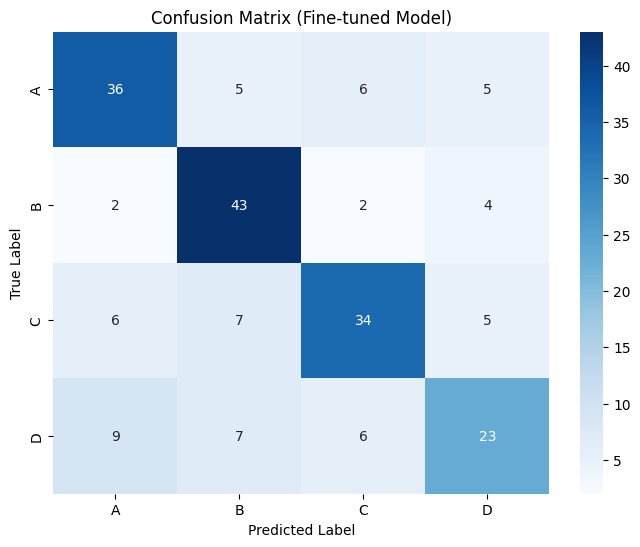

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LETTER_CHOICES,
    yticklabels=LETTER_CHOICES
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Fine-tuned Model)")
plt.show()

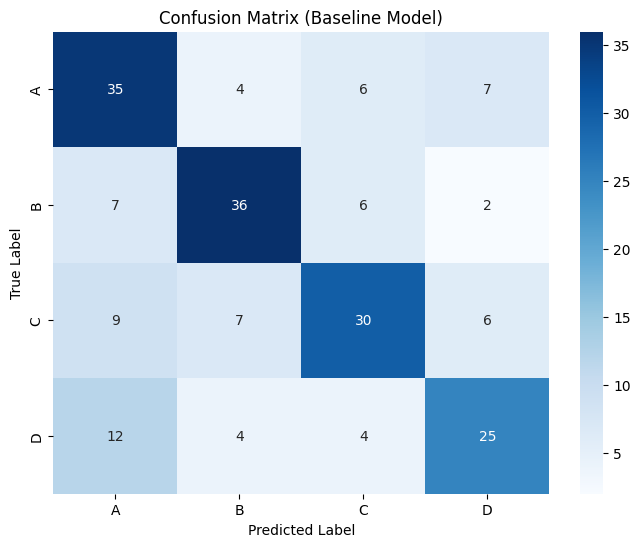

In [89]:
# 📊 Baseline evaluation
y_true_baseline = [test_ds[i]["target"] for i in range(N_PREVIEW)]
y_pred_baseline = [predict_label_baseline(test_ds[i]["prompt"]) for i in range(N_PREVIEW)]

# Calculate the confusion matrix for the baseline model
cm_baseline = confusion_matrix(y_true_baseline, y_pred_baseline, labels=LETTER_CHOICES)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LETTER_CHOICES,
    yticklabels=LETTER_CHOICES
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Baseline Model)")
plt.show()